<a href="https://colab.research.google.com/github/Thuy0684/HOCMAYNANGCAO/blob/main/LinearRegresstion_pip_install_pandas_matplotlib_seaborn_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CÀI THƯ VIỆN

In [1]:
%pip install pandas matplotlib seaborn scikit-learn

In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

RAW DỮ LIỆU TỪ GITHUB

In [36]:
df=pd.read_csv('https://raw.githubusercontent.com/Thuy0684/HOCMAYNANGCAO/refs/heads/main/HOMES_MISS.csv')

HIỂN THỊ DỮ LIỆU

In [37]:
df.head()

,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
0,400000,414000,2704,2.27,27,4920,9,3.0,3
1,370000,379000,2096,0.75,21,4113,8,4.0,2
2,382500,389900,2737,1.00,36,6072,9,4.0,2
3,300000,299900,1800,0.43,34,4024,8,NaN,2
4,305000,319900,1066,3.60,69,3562,6,NaN,2


TIỀN XỬ LÝ DỮ LIỆU

KIỂM TRA DỮ LIỆU

In [38]:
#2.1 KIỂM TRA KÍCH THƯỚC DỮ LIỆU (số dòng - số cột)
df.shape

(40, 9)

In [39]:
#2.2 Kiểm tra dữ liệu trống ở các cột
df.isnull().sum()

,0
Selling_Price,0
List_Price,0
Area,0
Acres,0
Age,0
Taxes,0
Rooms,0
Bedrooms,3
Baths_full,0


In [40]:
#2.2 Kiểm tra tổng quan về dữ liệu
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  40 non-null     int64  
 1   List_Price     40 non-null     int64  
 2   Area           40 non-null     int64  
 3   Acres          40 non-null     float64
 4   Age            40 non-null     int64  
 5   Taxes          40 non-null     int64  
 6   Rooms          40 non-null     int64  
 7   Bedrooms       37 non-null     float64
 8   Baths_full     40 non-null     int64  
dtypes: float64(2), int64(7)
memory usage: 2.9 KB


TIỀN XỬ LÝ DỮ LIỆU SAU KHI KIỂM TRA

In [47]:
# Cách 1: Xóa thẳng tay các dòng chứa ô trống (Nhanh nhất, khuyên dùng nếu số lượng dòng thiếu rất ít)
#df_clean = df.dropna()

# Cách 2: Lấp đầy ô trống bằng giá trị trung bình (Dành cho các cột số, ví dụ cột 'Area' bị thiếu)
# Điền số 0 vào tất cả các ô bị thiếu trong cột 'Pool'
df['Bedrooms'] = df['Bedrooms'].fillna(2)

In [48]:
df.isnull().sum()

,0
Selling_Price,0
List_Price,0
Area,0
Acres,0
Age,0
Taxes,0
Rooms,0
Bedrooms,0
Baths_full,0


XÁC ĐỊNH TẬP X LÀ CÁC DỮ LIỆU CÒN LẠI TRỪ CỘT SELLING PRICE
TẬP TAGET LÀ SELLING PRICE

In [50]:
X=df.drop(columns=['Selling_Price'])
Y=df['Selling_Price']

CHIA TẬP TEST VÀ TẬP TRAIN

In [51]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

CHỌN MÔN HÌNH HUẤN LUYỆN LÀ LINEARREGRESSION

In [52]:
model=LinearRegression()
model.fit(X_train,Y_train)
print("Huan luyen mo hinh thnah cong")

Huan luyen mo hinh thnah cong


DỰ ĐOÁN

In [53]:
pre_dic=model.predict(X_test)
print(Y_test.values)
print(pre_dic)

[272500 280000 475000 499000 305000 385000 300000 292000]
[270811.21753034 283281.5797674  477303.86812794 500607.87180891
 316643.8407486  374286.56193875 300916.56941449 291088.10531928]


ĐÁNH GIÁ

In [54]:
mse=mean_squared_error(Y_test,pre_dic)
r2=r2_score(Y_test,pre_dic)
print(mse)
print(r2)

34192780.74695773
0.9952704806370783


In [55]:
# Lấy hệ số chặn (b)
b = model.intercept_

# Lấy các trọng số (w_1, w_2,...)
w = model.coef_

# Tạo chuỗi phương trình
equation = f"y = {b:.2f}"

# Duyệt qua từng cột trong tập X và trọng số tương ứng ghép vào phương trình
for i, col_name in enumerate(X.columns):
    # Dùng dấu + hoặc - tùy thuộc vào giá trị của trọng số là âm hay dương
    if w[i] >= 0:
        equation += f" + {w[i]:.2f}*{col_name}"
    else:
        equation += f" - {abs(w[i]):.2f}*{col_name}"

# In kết quả
print("Phương trình hồi quy của bạn là:")
print(equation)

Phương trình hồi quy của bạn là:
y = 7393.29 + 1.01*List_Price + 3.41*Area + 295.13*Acres - 27.76*Age - 2.46*Taxes - 2325.87*Rooms - 777.74*Bedrooms + 3822.31*Baths_full


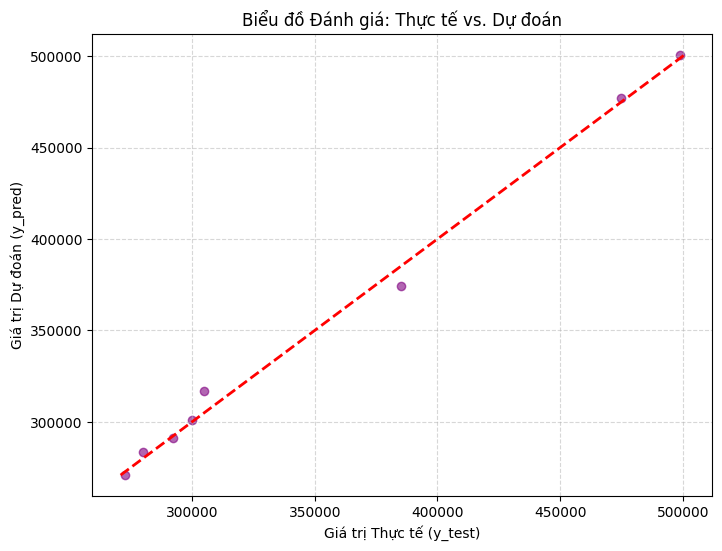

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# Vẽ các điểm: Trục X là Thực tế, Trục Y là Dự đoán
plt.scatter(Y_test, pre_dic, color='purple', alpha=0.6)

# Vẽ đường chéo y = x (Đường chuẩn)
# Nếu mô hình dự đoán đúng 100%, tất cả các điểm sẽ nằm đè lên đường đỏ này
min_val = min(Y_test.min(), pre_dic.min())
max_val = max(Y_test.max(), pre_dic.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.xlabel('Giá trị Thực tế (y_test)')
plt.ylabel('Giá trị Dự đoán (y_pred)')
plt.title('Biểu đồ Đánh giá: Thực tế vs. Dự đoán')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()